# Distribution Feeder Synthesis from a Reference Grid

Demonstrates the **Schweitzer et al. (2017)** synthesis pipeline starting from a real/reference
distribution grid (CIGRE LV via pandapower).

**Workflow:** Load reference grid → Convert to Schweitzer format → Fit parameters → Generate synthetic feeders → Validate & compare

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter

import pandapower as pp
import pandapower.networks as pn

from powergrid_synth import (
    GridVisualizer,
    GraphComparator,
    DistributionGrid,
)
from powergrid_synth.distribution import (
    SchweetzerFeederGenerator,
    DistributionSynthParams,
    compute_emergent_properties,
    validate_tree,
    compare_feeders,
    fit_params_from_feeders,
    pandapower_to_feeders,
    feeder_summary,
)

## 1. Load Reference Distribution Grid (CIGRE LV)

In [2]:
net_ref = pn.create_cigre_network_lv()
print(f"Buses: {len(net_ref.bus)}, Lines: {len(net_ref.line)}, Loads: {len(net_ref.load)}, Gens: {len(net_ref.sgen)}")
print(f"Ext grid bus: {net_ref.ext_grid.bus.values}")

Buses: 44, Lines: 37, Loads: 15, Gens: 0
Ext grid bus: [0]


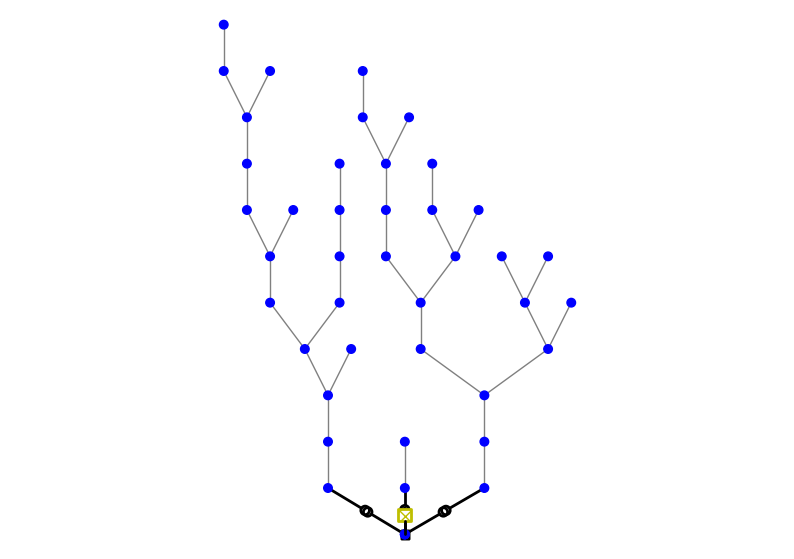

<Axes: >

In [3]:
fig, ax = plt.subplots(figsize=(10, 7))
pp.plotting.simple_plot(net_ref, ax=ax)

## 2. Convert Reference Grid to Schweitzer Format

The `pandapower_to_feeders` function from `powergrid_synth.distribution` extracts
Schweitzer-format feeder graphs from a pandapower network, handling lines,
transformers, and switches. We wrap the result as `DistributionGrid` objects to
access convenience properties like `.root`, `.max_hop`, `.total_load_mw`, etc.

In [4]:
raw_feeders = pandapower_to_feeders(net_ref)
ref_feeders = [DistributionGrid.from_nx(f) for f in raw_feeders]

In [5]:
print(f"Extracted {len(ref_feeders)} feeder(s) from reference grid\n")

for i, f in enumerate(ref_feeders):
    print(f"Feeder {i}: {f.number_of_nodes()} nodes, {f.number_of_edges()} edges")
    print(f"  Root: {f.root}, Max hop: {f.max_hop}, Is radial: {f.is_radial}")
    print(f"  Load nodes: {len(f.nodes_by_type('load'))}, "
          f"Injection: {len(f.nodes_by_type('injection'))}, "
          f"Intermediate: {len(f.nodes_by_type('intermediate'))}")
    print(f"  Total load: {f.total_load_mw:.4f} MW, Total gen: {f.total_gen_mw:.4f} MW")

Extracted 1 feeder(s) from reference grid

Feeder 0: 44 nodes, 43 edges
  Root: 0, Max hop: 12, Is radial: True
  Load nodes: 15, Injection: 0, Intermediate: 29
  Total load: 0.6866 MW, Total gen: 0.0000 MW


## 3. Fit Schweitzer Parameters from Reference Feeders

In [6]:
defaults = DistributionSynthParams()
fitted_raw = fit_params_from_feeders(ref_feeders)

# The CIGRE LV network is small (1 feeder, 44 nodes), so some fitted parameters
# may be degenerate. We merge fitted values with sensible defaults.
from powergrid_synth.distribution import ModifiedCauchyParams

fitted_params = DistributionSynthParams(
    hop_dist=fitted_raw.hop_dist,
    degree_dist=fitted_raw.degree_dist,
    degree_clip=fitted_raw.degree_clip,
    intermediate_frac=fitted_raw.intermediate_frac,
    injection_frac=fitted_raw.injection_frac,
    load_deviation=fitted_raw.load_deviation,
    # Use defaults for cable length if gamma is degenerate (≈0)
    cable_length=(
        fitted_raw.cable_length
        if fitted_raw.cable_length.gamma > 0.001
        else defaults.cable_length
    ),
    length_clip=fitted_raw.length_clip,
)

print(f"{'Parameter':35s} {'Paper (Table III)':>18s} {'Used':>18s}")
print("-" * 73)
print(f"{'hop_dist.r':35s} {defaults.hop_dist.r:18.3f} {fitted_params.hop_dist.r:18.3f}")
print(f"{'hop_dist.p':35s} {defaults.hop_dist.p:18.3f} {fitted_params.hop_dist.p:18.3f}")
print(f"{'degree_dist.pi':35s} {defaults.degree_dist.pi:18.3f} {fitted_params.degree_dist.pi:18.3f}")
print(f"{'cable_length.x0':35s} {defaults.cable_length.x0:18.3f} {fitted_params.cable_length.x0:18.3f}")
print(f"{'cable_length.gamma':35s} {defaults.cable_length.gamma:18.3f} {fitted_params.cable_length.gamma:18.3f}")

Parameter                            Paper (Table III)               Used
-------------------------------------------------------------------------
hop_dist.r                                       3.140             10.560
hop_dist.p                                       0.410              0.685
degree_dist.pi                                   0.850              0.762
cable_length.x0                                  0.119              0.119
cable_length.gamma                               0.159              0.159


## 4. Generate Synthetic Feeders Using Fitted Parameters

In [7]:
# Use the reference feeder's size and load as targets
ref = ref_feeders[0]
n_ref = ref.number_of_nodes()

print(f"Reference feeder: {n_ref} nodes, {ref.total_load_mw:.4f} MW load, {ref.total_gen_mw:.4f} MW gen")

# Generate a single synthetic feeder with fitted parameters
gen = SchweetzerFeederGenerator(params=fitted_params, seed=42)
G_syn = DistributionGrid.from_nx(
    gen.generate_feeder(
        n_nodes=n_ref,
        total_load_mw=ref.total_load_mw,
        total_gen_mw=ref.total_gen_mw,
        v_nom_kv=0.4,
    )
)

print(f"\nSynthetic feeder: {G_syn.number_of_nodes()} nodes, {G_syn.number_of_edges()} edges")
print(f"Root: {G_syn.root}, Max hop: {G_syn.max_hop}, Is radial: {G_syn.is_radial}")

Reference feeder: 44 nodes, 0.6866 MW load, 0.0000 MW gen

Synthetic feeder: 44 nodes, 43 edges
Root: 0, Max hop: 10, Is radial: True


## 5. Compare Reference vs. Synthetic Feeder Properties

In [8]:
props_ref = compute_emergent_properties(ref)
props_syn = compute_emergent_properties(G_syn)

print(f"{'Property':30s} {'Reference':>12s} {'Synthetic':>12s}")
print("-" * 56)
for key in props_ref:
    vr = props_ref[key]
    vs = props_syn.get(key, "N/A")
    if isinstance(vr, float):
        print(f"{key:30s} {vr:12.4f} {vs:12.4f}")
    else:
        print(f"{key:30s} {str(vr):>12s} {str(vs):>12s}")

# Also show DistributionGrid-specific properties
print(f"\n{'--- DistributionGrid properties ---':^56}")
print(f"{'root':30s} {str(ref.root):>12s} {str(G_syn.root):>12s}")
print(f"{'max_hop':30s} {ref.max_hop:12d} {G_syn.max_hop:12d}")
print(f"{'is_radial':30s} {str(ref.is_radial):>12s} {str(G_syn.is_radial):>12s}")
print(f"{'total_load_mw':30s} {ref.total_load_mw:12.4f} {G_syn.total_load_mw:12.4f}")
print(f"{'total_gen_mw':30s} {ref.total_gen_mw:12.4f} {G_syn.total_gen_mw:12.4f}")

Property                          Reference    Synthetic
--------------------------------------------------------
n_nodes                                  44           44
n_edges                                  43           43
max_hop                                  12           10
mean_degree                          1.9545       1.9545
total_load_mw                        0.6866       3.4176
total_gen_mw                              0            0
frac_intermediate                    0.6591       0.0455
frac_injection                       0.0000       0.0000
mean_length_km                       0.0319       0.0132
max_length_km                        0.2000       0.0295
total_length_km                      1.3730       0.5659

          --- DistributionGrid properties ---           
root                                      0            0
max_hop                                  12           10
is_radial                              True         True
total_load_mw                 

## 6. Visualize Reference and Synthetic Feeders

Calculating layout 'hierarchical_tree'...


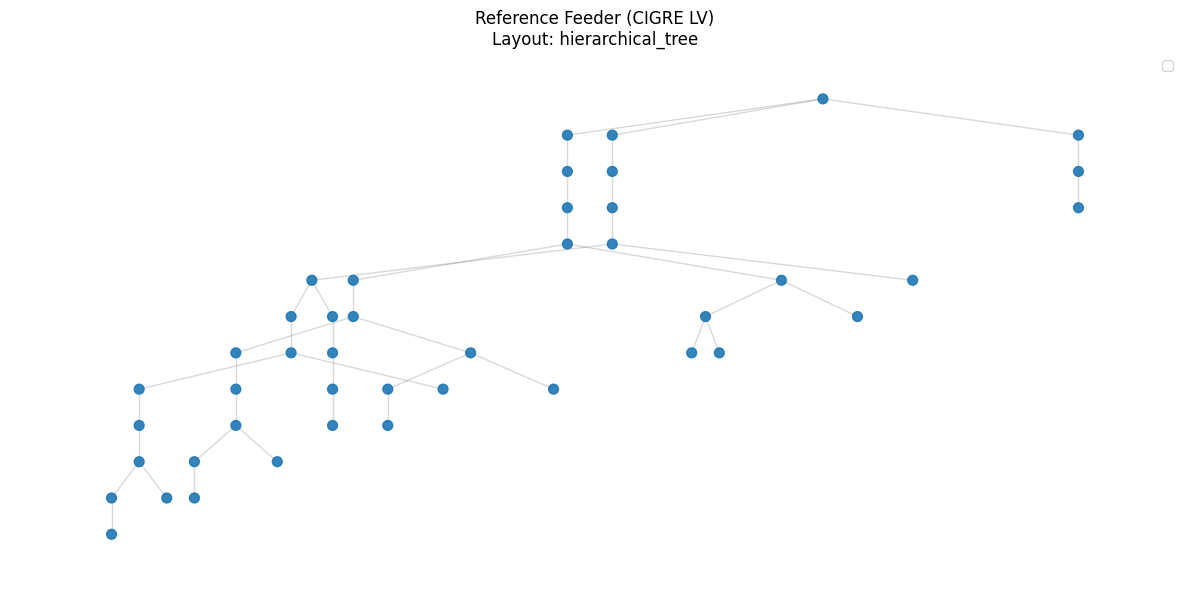

In [9]:
viz = GridVisualizer()

viz.plot_grid(
    ref,
    layout="hierarchical_tree",
    title="Reference Feeder (CIGRE LV)",
    figsize=(12, 6),
)

Calculating layout 'hierarchical_tree'...


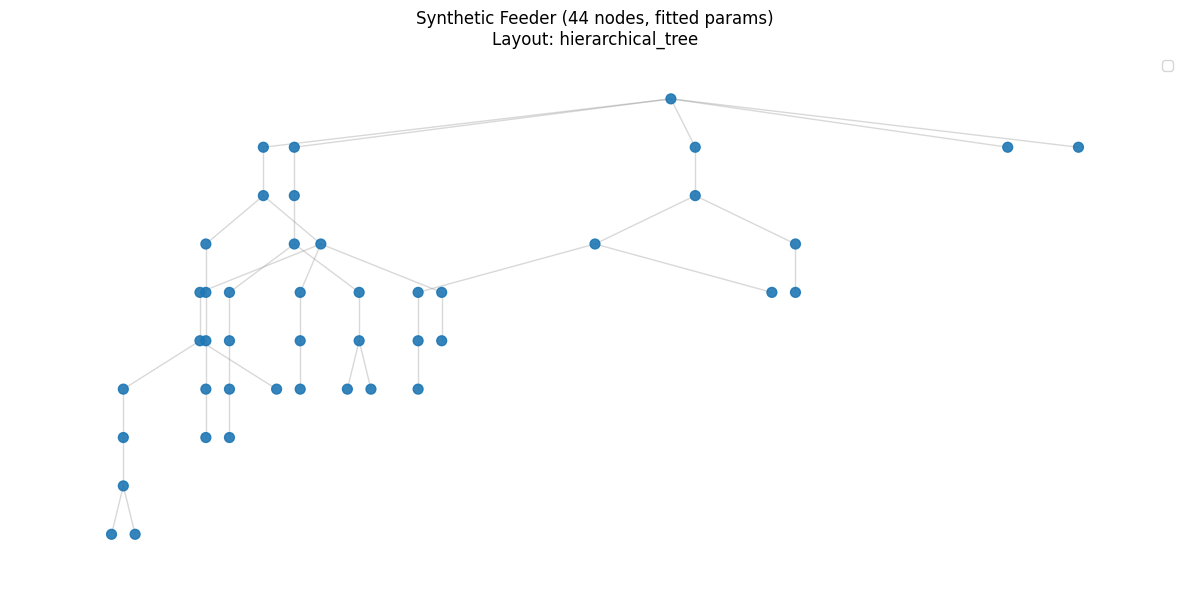

In [10]:
viz.plot_grid(
    G_syn,
    layout="hierarchical_tree",
    title=f"Synthetic Feeder ({n_ref} nodes, fitted params)",
    figsize=(12, 6),
)

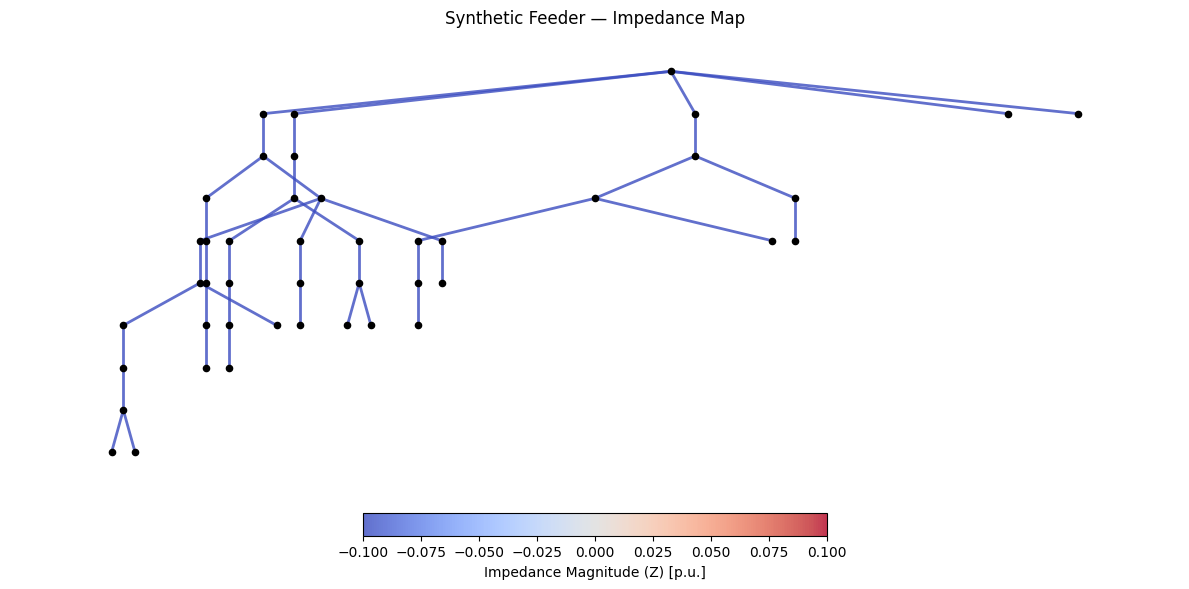

In [11]:
viz.plot_impedance(
    G_syn,
    layout="hierarchical_tree",
    title="Synthetic Feeder — Impedance Map",
    figsize=(12, 6),
)

## 7. Statistical Distribution Comparison

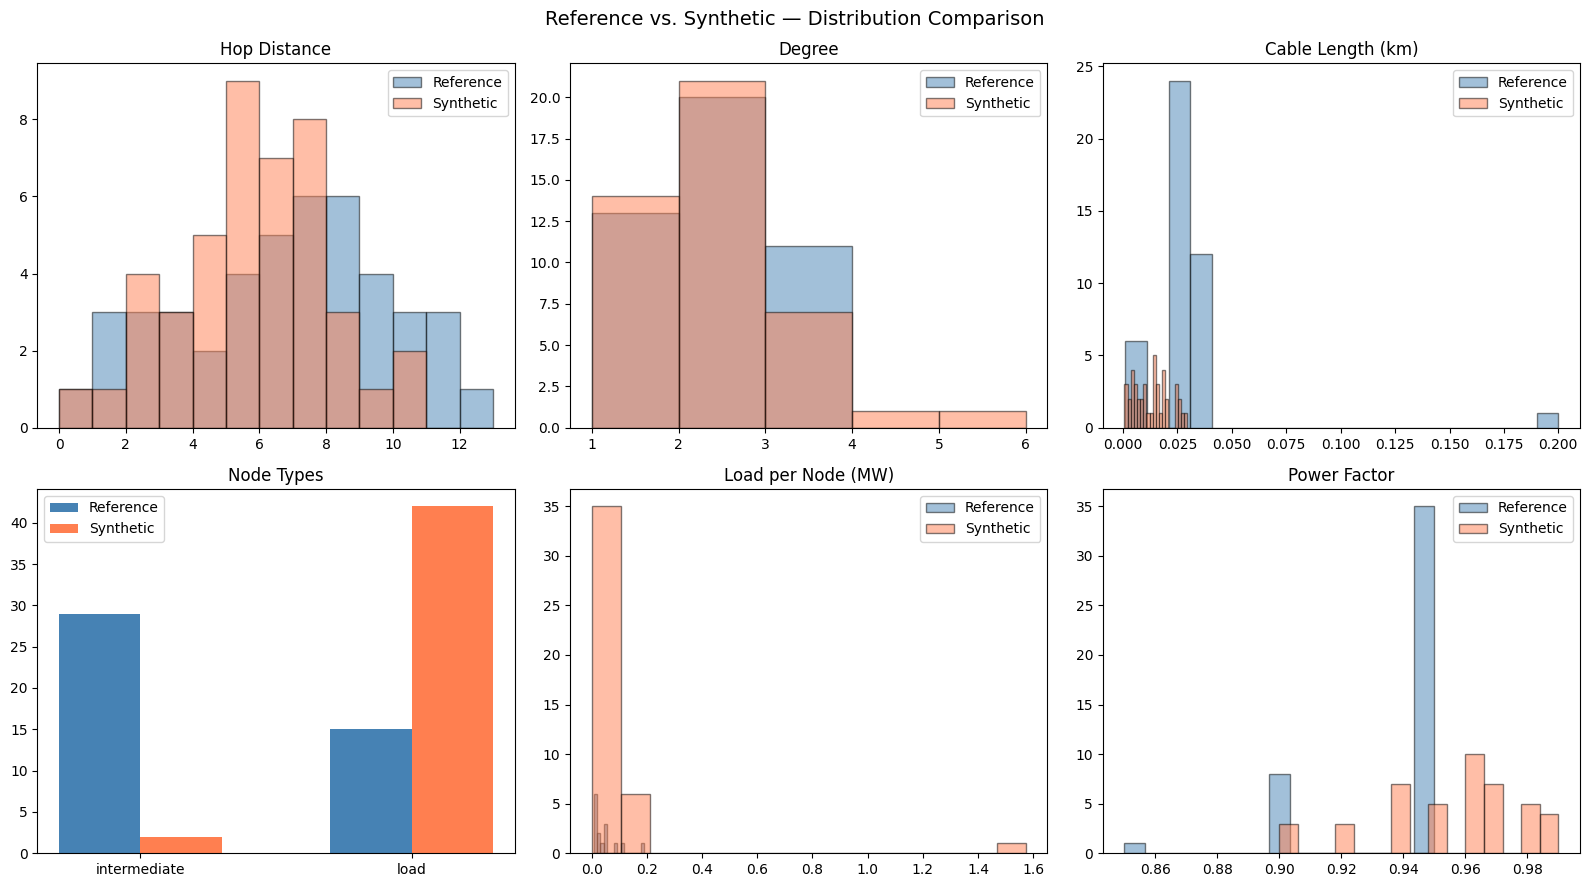

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# --- Hop distance ---
hops_ref = [ref.nodes[n]["h"] for n in ref.nodes]
hops_syn = [G_syn.nodes[n]["h"] for n in G_syn.nodes]
bins_h = range(max(max(hops_ref), max(hops_syn)) + 2)
axes[0, 0].hist(hops_ref, bins=bins_h, alpha=0.5, label="Reference", color="steelblue", edgecolor="black")
axes[0, 0].hist(hops_syn, bins=bins_h, alpha=0.5, label="Synthetic", color="coral", edgecolor="black")
axes[0, 0].set_title("Hop Distance")
axes[0, 0].legend()

# --- Degree ---
deg_ref = [d for _, d in ref.degree()]
deg_syn = [d for _, d in G_syn.degree()]
bins_d = range(1, max(max(deg_ref), max(deg_syn)) + 2)
axes[0, 1].hist(deg_ref, bins=bins_d, alpha=0.5, label="Reference", color="steelblue", edgecolor="black")
axes[0, 1].hist(deg_syn, bins=bins_d, alpha=0.5, label="Synthetic", color="coral", edgecolor="black")
axes[0, 1].set_title("Degree")
axes[0, 1].legend()

# --- Cable length ---
len_ref = [ref.edges[e]["length_km"] for e in ref.edges]
len_syn = [G_syn.edges[e]["length_km"] for e in G_syn.edges]
axes[0, 2].hist(len_ref, bins=20, alpha=0.5, label="Reference", color="steelblue", edgecolor="black")
axes[0, 2].hist(len_syn, bins=20, alpha=0.5, label="Synthetic", color="coral", edgecolor="black")
axes[0, 2].set_title("Cable Length (km)")
axes[0, 2].legend()

# --- Node types ---
types_ref = Counter(ref.nodes[n]["node_type"] for n in ref.nodes)
types_syn = Counter(G_syn.nodes[n]["node_type"] for n in G_syn.nodes)
all_types = sorted(set(types_ref) | set(types_syn))
x_pos = np.arange(len(all_types))
axes[1, 0].bar(x_pos - 0.15, [types_ref.get(t, 0) for t in all_types], 0.3, label="Reference", color="steelblue")
axes[1, 0].bar(x_pos + 0.15, [types_syn.get(t, 0) for t in all_types], 0.3, label="Synthetic", color="coral")
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(all_types)
axes[1, 0].set_title("Node Types")
axes[1, 0].legend()

# --- Load per node ---
loads_ref = [ref.nodes[n]["P_mw"] for n in ref.nodes if ref.nodes[n].get("P_mw", 0) > 0]
loads_syn = [G_syn.nodes[n]["P_mw"] for n in G_syn.nodes if G_syn.nodes[n].get("P_mw", 0) > 0]
axes[1, 1].hist(loads_ref, bins=15, alpha=0.5, label="Reference", color="steelblue", edgecolor="black")
axes[1, 1].hist(loads_syn, bins=15, alpha=0.5, label="Synthetic", color="coral", edgecolor="black")
axes[1, 1].set_title("Load per Node (MW)")
axes[1, 1].legend()

# --- Power factor ---
pf_ref = [ref.nodes[n]["pf"] for n in ref.nodes]
pf_syn = [G_syn.nodes[n]["pf"] for n in G_syn.nodes]
axes[1, 2].hist(pf_ref, bins=15, alpha=0.5, label="Reference", color="steelblue", edgecolor="black")
axes[1, 2].hist(pf_syn, bins=15, alpha=0.5, label="Synthetic", color="coral", edgecolor="black")
axes[1, 2].set_title("Power Factor")
axes[1, 2].legend()

plt.suptitle("Reference vs. Synthetic — Distribution Comparison", fontsize=14)
plt.tight_layout()
plt.show()

## 8. Generate an Ensemble and Aggregate Comparison

Generated 10 synthetic feeders

  Feeder 0: 44 nodes, max_hop=14, load=3.3174 MW, radial=True
  Feeder 1: 44 nodes, max_hop=11, load=0.5576 MW, radial=True
  Feeder 2: 44 nodes, max_hop=12, load=0.7935 MW, radial=True
  Feeder 3: 44 nodes, max_hop=13, load=0.4644 MW, radial=True
  Feeder 4: 44 nodes, max_hop=12, load=0.5117 MW, radial=True
  Feeder 5: 44 nodes, max_hop=11, load=2.5460 MW, radial=True
  Feeder 6: 44 nodes, max_hop=13, load=1.0276 MW, radial=True
  Feeder 7: 44 nodes, max_hop=11, load=2.2155 MW, radial=True
  Feeder 8: 44 nodes, max_hop=13, load=1.3603 MW, radial=True
  Feeder 9: 44 nodes, max_hop=13, load=0.5830 MW, radial=True

DISTRIBUTION FEEDER COMPARISON
            Metric Synthetic CIGRE LV
             Nodes        44       44
             Edges        43       43
           Density  0.045455 0.045455
        Connected?       Yes      Yes
    Diameter (LCC)        16       23
Avg Path Len (LCC)    6.9979   9.0433
    Avg Clustering    0.0000   0.0000
      Transi

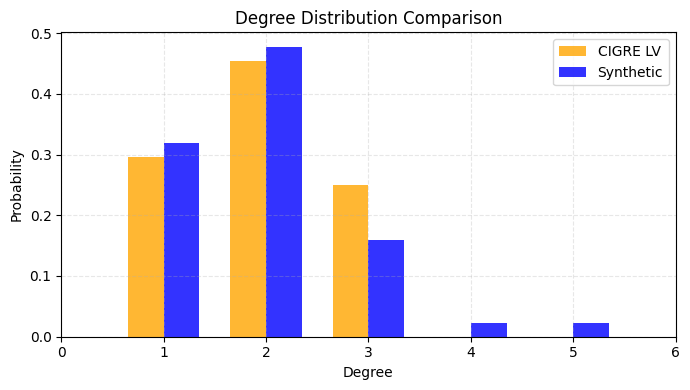

In [13]:
# Generate 10 synthetic feeders matching the reference size
ensemble = []
for seed in range(10):
    g = SchweetzerFeederGenerator(params=fitted_params, seed=seed)
    feeder = DistributionGrid.from_nx(
        g.generate_feeder(
            n_nodes=n_ref,
            total_load_mw=ref.total_load_mw,
            total_gen_mw=ref.total_gen_mw,
            v_nom_kv=0.4,
        )
    )
    ensemble.append(feeder)

print(f"Generated {len(ensemble)} synthetic feeders\n")
for i, f in enumerate(ensemble):
    print(f"  Feeder {i}: {f.number_of_nodes()} nodes, max_hop={f.max_hop}, "
          f"load={f.total_load_mw:.4f} MW, radial={f.is_radial}")

# Use GraphComparator for the first synthetic feeder vs reference
comparator = GraphComparator(
    synth_graph=G_syn,
    ref_graph=ref,
    synth_label="Synthetic",
    ref_label="CIGRE LV",
)
comparator.print_metric_comparison(title="DISTRIBUTION FEEDER COMPARISON")
comparator.plot_degree_comparison(log_scale=False, fig_size=(7, 4), show_lines=True)

## 9. KL-Divergence: Ensemble vs. Reference

In [14]:
# Compare each synthetic feeder against the reference
all_kl = []
for i, f in enumerate(ensemble):
    kl = compare_feeders(ref, f)
    all_kl.append(kl)
    print(f"Feeder {i}: " + ", ".join(f"{k}={v:.4f}" for k, v in kl.items()))

# Average KL-divergences across ensemble
print("\n--- Average KL-divergence (ensemble vs. reference) ---")
metrics = list(all_kl[0].keys())
for m in metrics:
    vals = [kl[m] for kl in all_kl]
    print(f"  {m:25s} mean={np.mean(vals):.4f}  std={np.std(vals):.4f}")

Feeder 0: hop_distance_kl=0.2300, degree_kl=0.1482, cable_length_kl=2.3346
Feeder 1: hop_distance_kl=0.6917, degree_kl=0.0707, cable_length_kl=9.2128
Feeder 2: hop_distance_kl=0.2736, degree_kl=0.3058, cable_length_kl=9.2062
Feeder 3: hop_distance_kl=0.1685, degree_kl=0.0280, cable_length_kl=9.1518
Feeder 4: hop_distance_kl=0.1931, degree_kl=0.0316, cable_length_kl=8.9255
Feeder 5: hop_distance_kl=0.7499, degree_kl=0.0316, cable_length_kl=9.2377
Feeder 6: hop_distance_kl=0.2124, degree_kl=0.1075, cable_length_kl=22.8413
Feeder 7: hop_distance_kl=0.6432, degree_kl=0.0477, cable_length_kl=8.8059
Feeder 8: hop_distance_kl=0.2281, degree_kl=0.1202, cable_length_kl=9.5514
Feeder 9: hop_distance_kl=0.2072, degree_kl=0.0477, cable_length_kl=8.9631

--- Average KL-divergence (ensemble vs. reference) ---
  hop_distance_kl           mean=0.3598  std=0.2222
  degree_kl                 mean=0.0939  std=0.0810
  cable_length_kl           mean=9.8230  std=4.7932


## 10. Side-by-Side Visualization

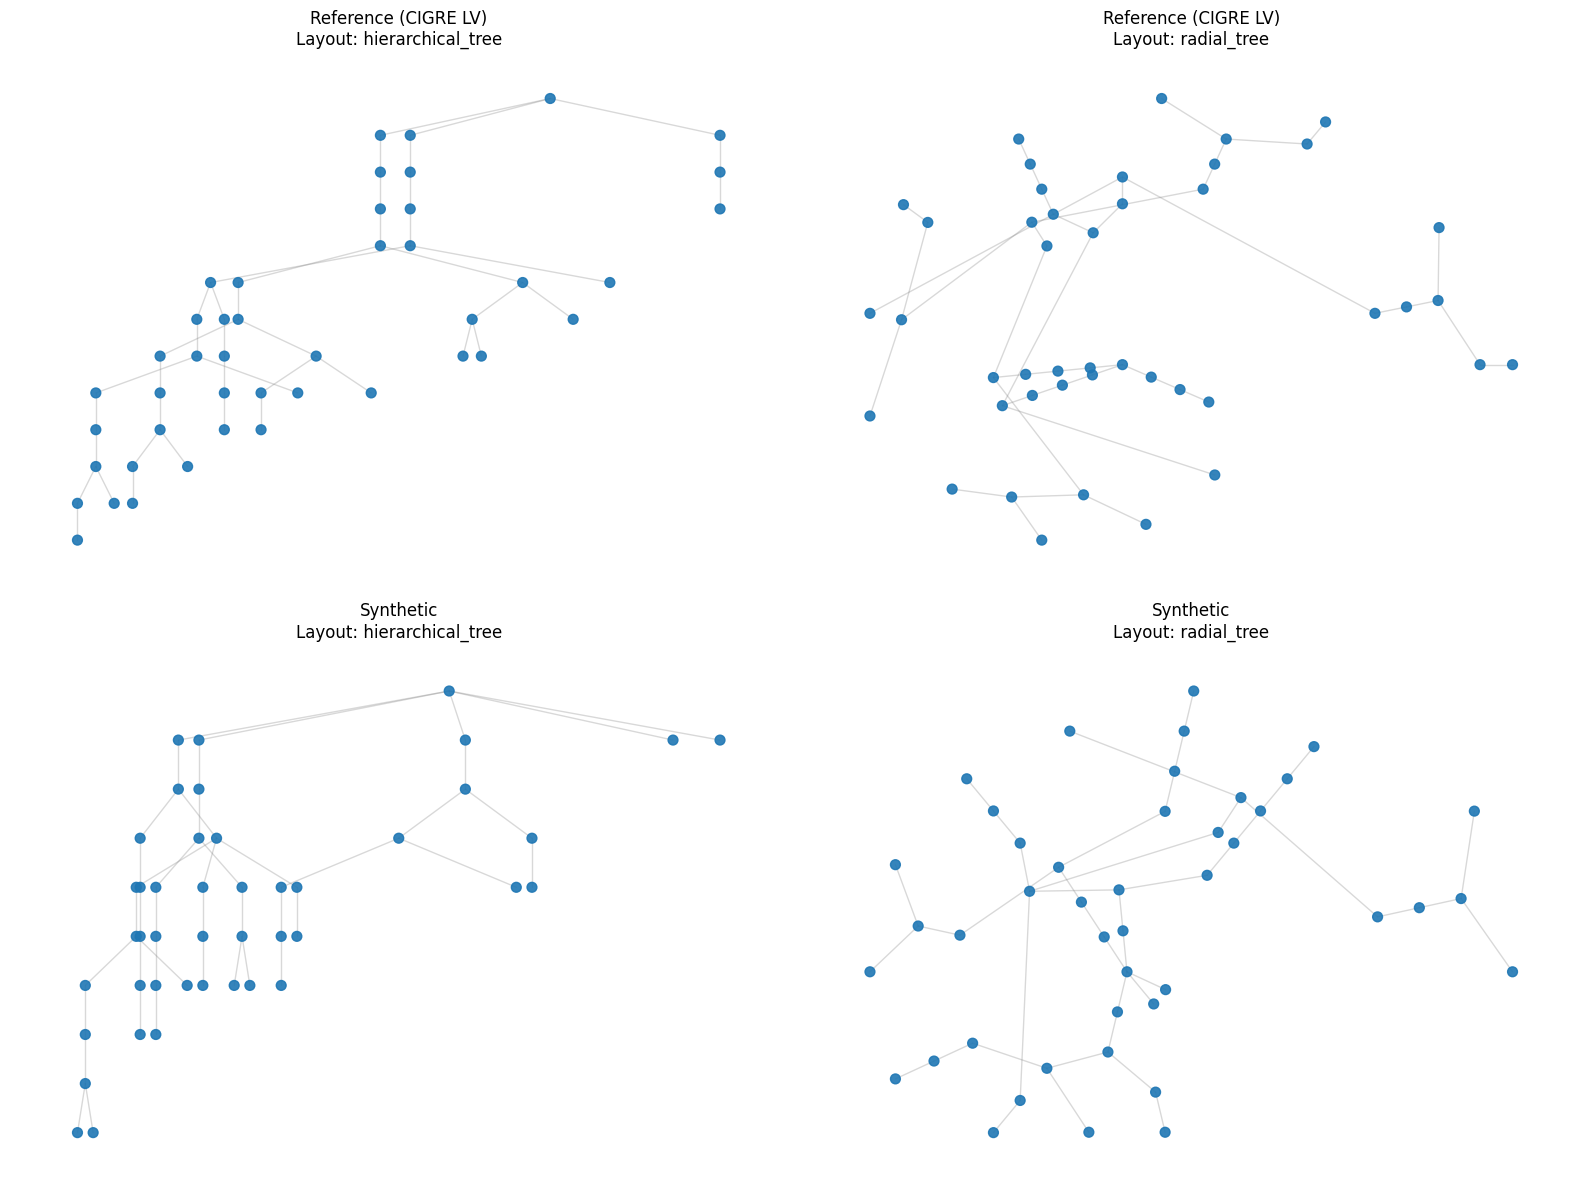

In [15]:
# Side-by-side: Reference vs Synthetic with tree layouts
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for col, lname in enumerate(["hierarchical_tree", "radial_tree"]):
    for row, (g, label) in enumerate([(ref, "Reference (CIGRE LV)"), (G_syn, "Synthetic")]):
        ax = axes[row, col]
        if lname == "hierarchical_tree":
            pos = viz._hierarchical_tree_layout(g)
        else:
            pos = viz._radial_tree_layout(g)
        colors = viz._get_node_colors(g)
        nx.draw_networkx_edges(g, pos, ax=ax, alpha=0.3, edge_color="gray")
        nx.draw_networkx_nodes(g, pos, ax=ax, node_color=colors, node_size=50, alpha=0.9)
        ax.set_title(f"{label}\nLayout: {lname}")
        ax.axis("off")

plt.tight_layout()
plt.show()